In [1]:
# Librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder

In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from pylab import rcParams
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedBaggingClassifier
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Proyecto Final

 **Integrantes**:
- Román Pardo Alejandro
- Riubi Zuñiga Andrey
- Salazar Vega Rodrigo
- Verduzco Lozano Iván Antonio

El objetivo principal de este proyecto es 'Predecir los proveedores potencialmente fraudulentos' en función de las reclamaciones presentadas por ellos. También descubriremos cuáles son las variables más importantes que ayudan a detectar el comportamiento de proveedores potencialmente fraudulentos para que podamos señalar dichos reclamos y realizar una investigación profunda sobre ellos.

Los significados de algunas variables son:

#### 1. Inpatient and outpatient data:
- **ClaimID:** esta es una identificación única para cada reclamo enviado.
- **Bene_ID:** contiene la identificación única de los beneficiarios registrados para el plan de seguro.
- **AttendingPhysician:** columna que contiene el id de los médicos que atendieron al paciente.
- **OperatingPhysician:** la columna contiene la identificación de los médicos que operaron al paciente.
- **ClmDiagnosisCode:** contiene códigos de diagnóstico que los proveedores realizan en los pacientes.
- **ClmProcedureCode:** contiene códigos de procedimientos a los que se someten los pacientes.
- **Proveedor:** identificación única de los proveedores de atención médica.
- **InscClaimAmtReimbursed:** monto total pagado al reclamante después de la liquidación.
- **ClaimStartDt / ClaimEndDt:** estas columnas tienen la fecha en que se presentaron los reclamos y la fecha en que se liquidaron los reclamos, respectivamente.
- **AdmissionDt / HighDt:** Fecha en que el paciente ingresó en el hospital y la fecha en que el paciente fue dado de alta. Aplicable solo para datos de pacientes hospitalizados.

#### 2. Beneficiaries data:
- **Bene_ID:** contiene la identificación única de los beneficiarios registrados para el plan de seguro.
- **DOB:** Fecha de nacimiento de los beneficiarios registrados en el régimen de seguro.
- **Gender:** Género de los beneficiarios registrados en el régimen de seguro.
- **State/Country:** contiene el código de estado/país para los miembros registrados.
- **Premedical conditions:** hay algunas columnas como RenalDiseaseIndicator, ChronicCond_Depression, ChronicCond_Diabetes, etc. para indicar si el miembro tiene alguna condición médica previa.

#### 3. Target data:
- **Provider:** esta es una identificación única para cada uno de los proveedores de atención médica.
- **Target:** esta columna tiene dos valores, Sí y No, que indican si el proveedor correspondiente está marcado como fraude potencial o no.

In [3]:
# Load Train Dataset

Train=pd.read_csv("./data proyecto/Train-1542865627584.csv")
Train_Beneficiarydata=pd.read_csv("./data proyecto/Train_Beneficiarydata-1542865627584.csv")
Train_Inpatientdata=pd.read_csv("./data proyecto/Train_Inpatientdata-1542865627584.csv")
Train_Outpatientdata=pd.read_csv("./data proyecto/Train_Outpatientdata-1542865627584.csv")

# Load Test Dataset

Test=pd.read_csv("./data proyecto/Test-1542969243754.csv")
Test_Beneficiarydata=pd.read_csv("./data proyecto/Test_Beneficiarydata-1542969243754.csv")
Test_Inpatientdata=pd.read_csv("./data proyecto/Test_Inpatientdata-1542969243754.csv")
Test_Outpatientdata=pd.read_csv("./data proyecto/Test_Outpatientdata-1542969243754.csv")

In [4]:
Train_Inpatientdata

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40469,BENE159167,CLM69886,2009-09-28,2009-10-02,PRV53671,7000,PHY345332,PHY319565,NaN,2009-09-28,...,79092,70704,2869,4148,9904.0,NaN,NaN,NaN,NaN,NaN
40470,BENE159175,CLM74504,2009-11-03,2009-11-06,PRV54981,4000,PHY342806,PHY365497,NaN,2009-11-03,...,49122,4254,5990,NaN,8605.0,NaN,NaN,NaN,NaN,NaN
40471,BENE159177,CLM76485,2009-11-18,2009-11-22,PRV56588,3000,PHY423220,PHY332752,NaN,2009-11-18,...,71534,71590,V4502,NaN,9390.0,NaN,NaN,NaN,NaN,NaN
40472,BENE159177,CLM79949,2009-12-17,2009-12-18,PRV56575,5000,PHY353156,NaN,NaN,2009-12-17,...,4263,0414,41400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
Train_Outpatientdata

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517732,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,2163,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
517733,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,07041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
517734,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,V570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
517735,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [6]:
Train_Beneficiarydata

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138551,BENE159194,1939-07-01,NaN,1,1,0,39,140,12,12,...,2,2,2,2,2,2,0,0,430,460
138552,BENE159195,1938-12-01,NaN,2,1,0,49,530,12,12,...,2,1,2,2,2,2,0,0,880,100
138553,BENE159196,1916-06-01,NaN,2,1,0,6,150,12,12,...,1,1,1,2,2,2,2000,1068,3240,1390
138554,BENE159197,1930-01-01,NaN,1,1,0,16,560,12,12,...,2,2,1,2,2,2,0,0,2650,10


In [7]:
Train

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No
...,...,...
5405,PRV57759,No
5406,PRV57760,No
5407,PRV57761,No
5408,PRV57762,No


In [8]:
unique_ben_inpat = Train_Inpatientdata['BeneID'].unique()
unique_ben_outpat = Train_Outpatientdata['BeneID'].unique()
valores_comunes = set(unique_ben_inpat) & set(unique_ben_outpat)
valores_comunes_lista = list(valores_comunes)

In [9]:
len(Train_Beneficiarydata['BeneID'].unique())

138556

In [10]:
len(unique_ben_inpat)

31289

In [11]:
len(valores_comunes_lista)

26713

In [12]:
len(unique_ben_outpat)

133980

Text(0, 0.5, 'Frecuencia')

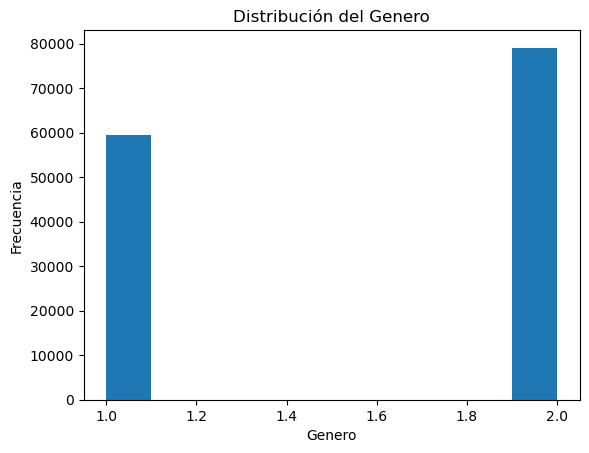

In [13]:
plt.hist(Train_Beneficiarydata['Gender'])
plt.title('Distribución del Genero')
plt.xlabel('Genero')
plt.ylabel('Frecuencia')

In [14]:
#Establecemos las calumnas con datos de tiempo en formato de fecha
Train_Beneficiarydata['DOD'] = pd.to_datetime(Train_Beneficiarydata['DOD'], format="%Y/%m/%d")
Train_Beneficiarydata['DOB'] = pd.to_datetime(Train_Beneficiarydata['DOB'], format="%Y/%m/%d")

Train_Outpatientdata['ClaimStartDt'] = pd.to_datetime(Train_Outpatientdata['ClaimStartDt'], format="%Y/%m/%d")
Train_Outpatientdata['ClaimEndDt'] = pd.to_datetime(Train_Outpatientdata['ClaimEndDt'], format="%Y/%m/%d")

Train_Inpatientdata['ClaimStartDt'] = pd.to_datetime(Train_Inpatientdata['ClaimStartDt'], format="%Y/%m/%d")
Train_Inpatientdata['ClaimEndDt'] = pd.to_datetime(Train_Inpatientdata['ClaimEndDt'], format="%Y/%m/%d")

In [15]:
#Calculamos le edad de los beneficiarios, tomando en cuenta la fecha del fallecimiento más reciente
t_dod = Train_Beneficiarydata['DOD'].unique()
t_dod = [x for x in t_dod if np.isnan(x) == False]
dod_max = max(t_dod)
Train_Beneficiarydata['DOD'].fillna(dod_max, inplace=True)
Train_Beneficiarydata['Age'] = np.round(((Train_Beneficiarydata['DOD'] - Train_Beneficiarydata['DOB']).dt.days)/365.0,0)

#Agregamos una columna para la duración de la reclamación
Train_Inpatientdata['CDT'] = (Train_Inpatientdata['ClaimEndDt'] - Train_Inpatientdata['ClaimStartDt']).dt.days
Train_Outpatientdata['CDT'] = (Train_Outpatientdata['ClaimEndDt'] - Train_Outpatientdata['ClaimStartDt']).dt.days

In [16]:
#Agregamos una columna que indique si es ingresado o no
Train_Inpatientdata['is_inpatient'] = 1
Train_Outpatientdata['is_inpatient'] = 0

#Unimos los datos de Pacientes In y Out
Train_hd = pd.concat([Train_Inpatientdata, Train_Outpatientdata], axis=0, ignore_index=True)

#Juntamos los datos del beneficiario y del provedor para fomrar el dataset a utilizar
Train_hd = pd.merge(Train_hd, Train_Beneficiarydata, on='BeneID')
Train_hd = pd.merge(Train_hd, Train[['Provider', 'PotentialFraud']], on='Provider', how='left')

In [17]:
Train_hd

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,2,1,1,36000,3204,60,70,67.0,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,2,1,1,36000,3204,60,70,67.0,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,2,1,1,36000,3204,60,70,67.0,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,2,2,1,1,5000,1068,250,320,96.0,No
4,BENE11011,CLM144521,2009-01-18,2009-01-18,PRV52314,50,PHY379398,NaN,NaN,NaN,...,2,2,1,1,5000,1068,250,320,96.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,NaN,...,2,2,1,2,0,0,5470,1870,58.0,No
558207,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,NaN,...,2,2,1,2,0,0,5470,1870,58.0,No
558208,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,NaN,...,2,2,1,2,0,0,5470,1870,58.0,No
558209,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaN,...,2,2,1,2,0,0,5470,1870,58.0,No


(array([212796.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 345415.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

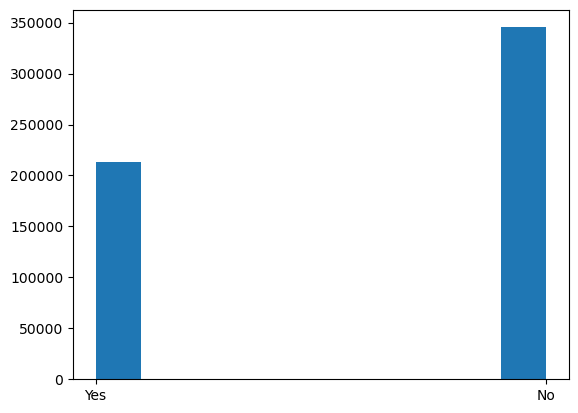

In [18]:
plt.hist(Train_hd.query('AttendingPhysician != "nan"')['PotentialFraud'])

(array([212796.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 345415.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

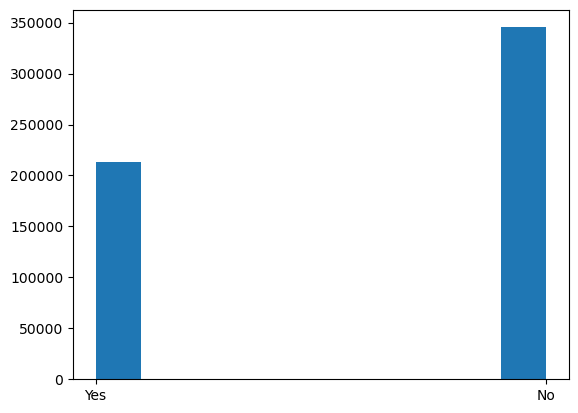

In [19]:
plt.hist(Train_hd.query('OperatingPhysician != "nan"')['PotentialFraud'])

Text(0, 0.5, 'Frecuencia')

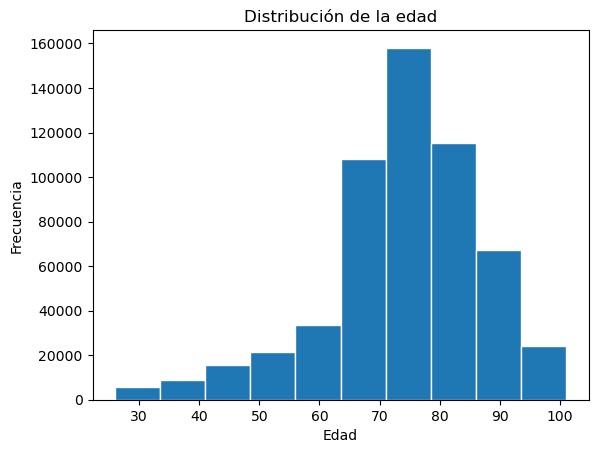

In [20]:
plt.hist(Train_hd.Age, edgecolor = 'white')
plt.title('Distribución de la edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

In [21]:
Train_hd.isnull().sum()

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1508
OperatingPhysician                 443764
OtherPhysician                     358475
AdmissionDt                        517737
ClmAdmitDiagnosisCode              412312
DeductibleAmtPaid                     899
DischargeDt                        517737
DiagnosisGroupCode                 517737
ClmDiagnosisCode_1                  10453
ClmDiagnosisCode_2                 195606
ClmDiagnosisCode_3                 315156
ClmDiagnosisCode_4                 393675
ClmDiagnosisCode_5                 446287
ClmDiagnosisCode_6                 473819
ClmDiagnosisCode_7                 492034
ClmDiagnosisCode_8                 504767
ClmDiagnosisCode_9                 516396
ClmDiagnosisCode_10               

In [22]:
#Realizamos diferencia entre el deducible y el reembolsable 
#Non-Hospitalization Reimbursement Deductible difference (NH_DMR)
#Hospitalization Reimbursement Deductible difference (H_DMR)

Train_hd2 = Train_hd

#Sustitutendo nulos con la moda 
Train_hd2['DeductibleAmtPaid'].fillna(0, inplace=True)

#Agregamos columna con la diferencia entre lo deducible y lo reembolsable
Train_hd2['DRD'] = Train_hd2['InscClaimAmtReimbursed'] - Train_hd2['DeductibleAmtPaid']
#Train_hd2['NH_DRD'] = Train_hd2['IPAnnualReimbursementAmt'] - Train_hd2['IPAnnualDeductibleAmt'] 
#Train_hd2['H_DRD'] = Train_hd2['OPAnnualReimbursementAmt'] - Train_hd2['OPAnnualDeductibleAmt']

#Cuantifica los códigos de procedimeintos
Train_hd2['ClmProcedureCode_count'] = Train_hd2['ClmProcedureCode_1'].notnull().astype(int) + Train_hd2['ClmProcedureCode_2'].notnull().astype(int) + Train_hd2['ClmProcedureCode_3'].notnull().astype(int) + Train_hd2['ClmProcedureCode_4'].notnull().astype(int) + Train_hd2['ClmProcedureCode_5'].notnull().astype(int) + Train_hd2['ClmProcedureCode_6'].notnull().astype(int)
Train_hd2.drop(['ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6'], axis=1, inplace=True)

#Cuantifica el número de códigos de diagnosticos
for i in range(1, 11):
    Train_hd2['ClmDiagnosisCode_count'] = Train_hd2['ClmDiagnosisCode_' + str(i)].notnull().astype(int)
Train_hd2.drop(['ClmDiagnosisCode_' + str(i) for i in range(1, 11)], axis=1, inplace=True)

#Agregamos una columna que indique si el paciente sufrió un operación
Train_hd2['Operating'] = Train_hd2['OperatingPhysician'].apply(lambda val: 0 if val != val else 1)

#Modificar al codificación de la columna de enfermefdad renal
Train_hd2['RenalDiseaseIndicator'] = Train_hd2['RenalDiseaseIndicator'].apply(lambda val: 0 if val != "Y" else 1).values

(array([1.99272e+05, 0.00000e+00, 1.02780e+04, 0.00000e+00, 2.68300e+03,
        0.00000e+00, 4.87000e+02, 0.00000e+00, 7.00000e+01, 6.00000e+00]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

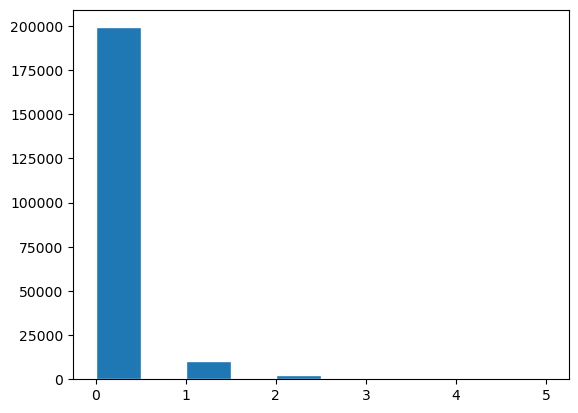

In [23]:
plt.hist(Train_hd2.query('PotentialFraud == "Yes"')['ClmProcedureCode_count'], edgecolor = 'white')

(array([2.07412e+05, 3.66700e+03, 9.36000e+02, 3.50000e+02, 3.58000e+02,
        2.00000e+01, 1.90000e+01, 1.40000e+01, 1.00000e+01, 1.00000e+01]),
 array([ -1068. ,  11438.8,  23945.6,  36452.4,  48959.2,  61466. ,
         73972.8,  86479.6,  98986.4, 111493.2, 124000. ]),
 <BarContainer object of 10 artists>)

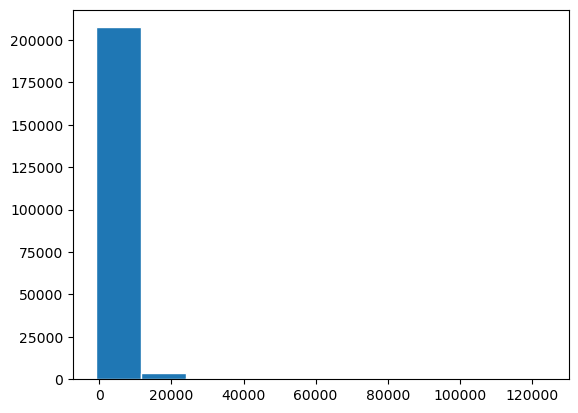

In [24]:
plt.hist(Train_hd2.query('PotentialFraud == "Yes"')['DRD'], edgecolor = 'white')

In [25]:
#Eliminamos columnas con formato de fecha
Train_hd2 = Train_hd2.drop(['ClaimStartDt', 'ClaimEndDt', 'DOB', 'DOD', 
                            'AdmissionDt', 'DischargeDt'], axis = 1)

#Eliminamos columnas que no aportan información
Train_hd2 = Train_hd2.drop(['BeneID', 'ClaimID', 'Provider', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 
    'AttendingPhysician','OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode', 'DiagnosisGroupCode'], axis = 1)


In [26]:
Train_hd2.isnull().sum()

InscClaimAmtReimbursed             0
DeductibleAmtPaid                  0
CDT                                0
is_inpatient                       0
Gender                             0
Race                               0
RenalDiseaseIndicator              0
State                              0
County                             0
ChronicCond_Alzheimer              0
ChronicCond_Heartfailure           0
ChronicCond_KidneyDisease          0
ChronicCond_Cancer                 0
ChronicCond_ObstrPulmonary         0
ChronicCond_Depression             0
ChronicCond_Diabetes               0
ChronicCond_IschemicHeart          0
ChronicCond_Osteoporasis           0
ChronicCond_rheumatoidarthritis    0
ChronicCond_stroke                 0
IPAnnualReimbursementAmt           0
IPAnnualDeductibleAmt              0
OPAnnualReimbursementAmt           0
OPAnnualDeductibleAmt              0
Age                                0
PotentialFraud                     0
DRD                                0
C

In [27]:
Train_hd2

,InscClaimAmtReimbursed,DeductibleAmtPaid,CDT,is_inpatient,Gender,Race,RenalDiseaseIndicator,State,County,ChronicCond_Alzheimer,...,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,DRD,ClmProcedureCode_count,ClmDiagnosisCode_count,Operating
0,26000,1068.0,6,1,1,1,0,39,230,1,...,36000,3204,60,70,67.0,Yes,24932.0,0,0,0
1,5000,1068.0,2,1,1,1,0,39,230,1,...,36000,3204,60,70,67.0,No,3932.0,1,0,1
2,5000,1068.0,3,1,1,1,0,39,230,1,...,36000,3204,60,70,67.0,No,3932.0,0,0,0
3,5000,1068.0,8,1,2,2,0,1,360,2,...,5000,1068,250,320,96.0,No,3932.0,1,0,1
4,50,0.0,0,0,2,2,0,1,360,2,...,5000,1068,250,320,96.0,No,50.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,800,0.0,0,0,2,1,0,21,20,1,...,0,0,5470,1870,58.0,No,800.0,0,0,1
558207,400,0.0,0,0,2,1,0,21,20,1,...,0,0,5470,1870,58.0,No,400.0,0,0,1
558208,60,0.0,0,0,2,1,0,21,20,1,...,0,0,5470,1870,58.0,No,60.0,0,0,0
558209,70,0.0,0,0,2,1,0,21,20,1,...,0,0,5470,1870,58.0,No,70.0,0,0,0


In [28]:
sc = MinMaxScaler()
X = Train_hd2.drop(['PotentialFraud'], axis = 1).values
Y = Train_hd2['PotentialFraud'].apply(lambda val: 0 if val != "Yes" else 1).values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    X, 
                                                    Y, 
                                                    test_size=0.2, 
                                                    shuffle = True, 
                                                    random_state = 42, 
                                                    stratify = Y
                                                    )

X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

mat_cov = np.cov(X_train_s.T)
eig_val, eig_vec = np.linalg.eig(mat_cov)
var_exp = [(i / sum(eig_val)) for i in sorted(eig_val, reverse = True)]
var_exp_cum = np.cumsum(var_exp)

In [30]:
# concat X_train and y_train
X_train_aux = np.concatenate((X_train_s, y_train.reshape(-1, 1)), axis = 1)
X_train_aux = pd.DataFrame(X_train_aux, columns = Train_hd2.columns)
X_train_aux.head()

,InscClaimAmtReimbursed,DeductibleAmtPaid,CDT,is_inpatient,Gender,Race,RenalDiseaseIndicator,State,County,ChronicCond_Alzheimer,...,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,DRD,ClmProcedureCode_count,ClmDiagnosisCode_count,Operating
0,0.00320,0.0,0.0,0.0,1.0,0.00,0.0,0.471698,0.050050,1.0,...,0.047206,0.000000,0.010871,0.009393,0.813333,0.011738,0.0,0.0,0.0,0.0
1,0.00008,0.0,0.0,0.0,1.0,0.00,0.0,0.716981,0.770771,1.0,...,0.047206,0.000000,0.008832,0.015896,0.813333,0.008619,0.0,0.0,0.0,1.0
2,0.00008,0.0,0.0,0.0,1.0,0.25,0.0,0.188679,0.290290,0.0,...,0.100372,0.055811,0.003203,0.002890,0.440000,0.008619,0.0,0.0,0.0,1.0
3,0.00048,0.0,0.0,0.0,1.0,0.00,0.0,0.811321,0.820821,1.0,...,0.047206,0.000000,0.018635,0.022399,0.653333,0.009019,0.0,0.0,0.0,1.0
4,0.00056,0.0,0.0,0.0,0.0,0.00,0.0,0.584906,0.000000,1.0,...,0.047206,0.000000,0.007182,0.091040,0.666667,0.009099,0.0,0.0,0.0,1.0


In [31]:
# With X_aux, get the features with the highest correlation with the target
corr = X_train_aux.corr()
corr_target = abs(corr['PotentialFraud'])
relevant_features = corr_target[corr_target > 0.1]
relevant_features

InscClaimAmtReimbursed      0.998388
DeductibleAmtPaid           0.608694
CDT                         0.254299
is_inpatient                0.621615
IPAnnualReimbursementAmt    0.381264
IPAnnualDeductibleAmt       0.214465
PotentialFraud              1.000000
DRD                         0.606455
ClmProcedureCode_count      0.215871
ClmDiagnosisCode_count      0.251027
Name: PotentialFraud, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

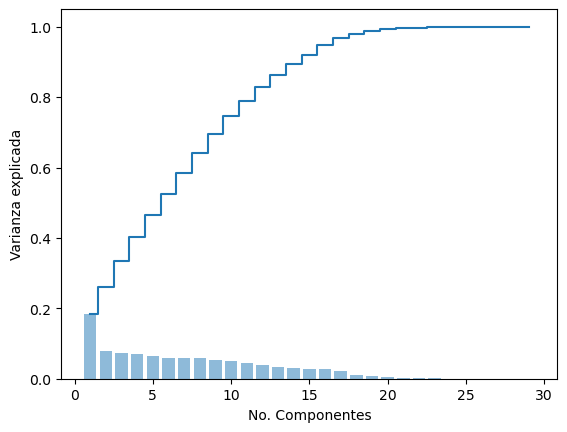

In [32]:
plt.bar(range(1, len(eig_val) + 1), var_exp, alpha = 0.5, align = 'center')
plt.step(range(1, len(eig_val) + 1), var_exp_cum, where = 'mid')
plt.xlabel('No. Componentes')
plt.ylabel('Varianza explicada')
plt.show

In [33]:
pca = PCA(n_components = 20)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

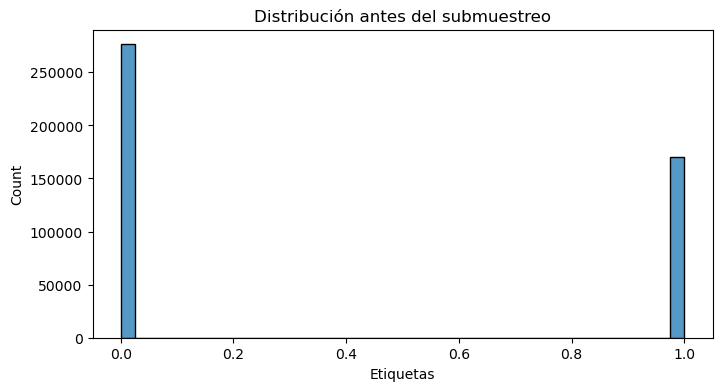

In [34]:
fig, ax = plt.subplots(nrows=1, figsize=(8, 4))
sns.histplot(y_train, ax=ax)
plt.title('Distribución antes del submuestreo')
_ = plt.xlabel('Etiquetas')

In [35]:
# Codigo del submuestreo
nm = NearMiss(version= 1, n_neighbors=5)
X_train_sub, y_train_sub = nm.fit_resample(X_train_pca, y_train)
X_test_sub, y_test_sub = nm.fit_resample(X_test_pca, y_test)
print('Antes del submuestreo de y: ', Counter(y_train))
print('Muestras submuestradas de y: ', Counter(y_train_sub))

print(type(y_test_sub))
print('Antes del submuestreo de test: ', Counter(y_test))
print('Despues del submuestreo de test: ', Counter(y_test_sub))
# print('Muestras submuestradas de test: ', Counter(X_test_sub))

Antes del submuestreo de y:  Counter({0: 276332, 1: 170236})
Muestras submuestradas de y:  Counter({0: 170236, 1: 170236})
<class 'numpy.ndarray'>
Antes del submuestreo de test:  Counter({0: 69083, 1: 42560})
Despues del submuestreo de test:  Counter({0: 42560, 1: 42560})


In [36]:
def metricas(real, predict):
    print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(real, predict))
    print('Mean Squared Error (MSE):', metrics.mean_squared_error(real, predict))
    print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(real, predict)))
    mape = np.mean(np.abs((real - predict) / np.abs(real)))
    print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
    print('Accuracy:', round(100*(1 - mape), 2))

    # display confusion_matrix
    cm = confusion_matrix(real, predict, labels=np.unique(real))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=np.unique(real))
    disp.plot()

Mean Absolute Error (MAE): 0.3647967181104055
Mean Squared Error (MSE): 0.3647967181104055
Root Mean Squared Error (RMSE): 0.6039840379599493
Mean Absolute Percentage Error (MAPE): nan
Accuracy: nan


C:\Users\Iván\AppData\Local\Temp\ipykernel_8436\190597009.py:5: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((real - predict) / np.abs(real)))
C:\Users\Iván\AppData\Local\Temp\ipykernel_8436\190597009.py:5: RuntimeWarning: invalid value encountered in divide
  mape = np.mean(np.abs((real - predict) / np.abs(real)))


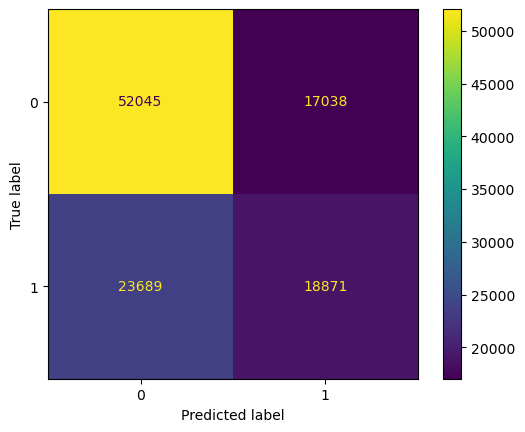

In [37]:
#K-NN 

knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
metricas(y_test, y_pred)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=7c4b0dbe-cd7e-4104-91e5-9f2fe576b62b' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>